*Topic*: Data Science  
*Author*: Luz Enseñat de Carlos

# Diabetes Readmission Predictive Analysis

We will perform an Exploratory Data Analysis (EDA) using Python.

We have a dataset containing information about hospital admissions of diabetic patients. The final objective of this project is to study the clinical history of each patient in order to identify which patients have a high probability of being readmitted within the next 30 days due to diabetes-related complications.

The following link contains a description of all dataset columns:

## 1.- Library Import

First, we import the libraries that will be used throughout the analysis: Pandas, Matplotlib, Seaborn, and SciPy Stats.

Additionally, since the dataset contains many columns and Pandas truncates them by default when displaying DataFrames, we modify this configuration.

In [167]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import scipy.stats
from scipy import stats
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
from scipy.stats import chi2_contingency

# Para que se muestren todas las columnas del DataFrame:

pd.options.display.max_columns = 100

## 2.- Data Loading

We read the DataFrame from the CSV file `datos/diabetes.csv` and verify that everything loaded correctly by displaying the first five rows.

In [168]:
df = pd.read_csv("https://raw.githubusercontent.com/Luz-Ensenat/Diabetes-Readmission-Predictive-Analysis/main/data/diabetes.csv")
df.head(5)

,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,primary_diagnosis,number_diagnoses,max_glu_serum,A1Cresult,insulin,change,diabetesMed,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days,readmitted,readmit_binary,readmit_30_days
0,Caucasian,Female,30 years or younger,Other,Referral,1,Other,41,0,1,Diabetes,1,NaN,NaN,No,No,No,False,False,False,False,False,NO,0,0
1,Caucasian,Female,30 years or younger,Discharged to Home,Emergency,3,Missing,59,0,18,Other,9,NaN,NaN,Up,Ch,Yes,False,False,False,False,False,>30,1,0
2,AfricanAmerican,Female,30 years or younger,Discharged to Home,Emergency,2,Missing,11,5,13,Other,6,NaN,NaN,No,No,Yes,False,False,False,True,True,NO,0,0
3,Caucasian,Male,30-60 years,Discharged to Home,Emergency,2,Missing,44,1,16,Other,7,NaN,NaN,Up,Ch,Yes,False,False,False,False,False,NO,0,0
4,Caucasian,Male,30-60 years,Discharged to Home,Emergency,1,Missing,51,0,8,Other,5,NaN,NaN,Steady,Ch,Yes,False,False,False,False,False,NO,0,0


## 3.- Univariate Analysis

### 3.1.- Identification and Handling of Missing Values

We count how many missing values each variable contains and the percentage they represent:

In [169]:
# Count missing values per column:

numero_nulos = df.isnull().sum()
porcentaje_nulos = (numero_nulos / len(df)) * 100

print(f'The number of missing values per column is:\n\n{numero_nulos}')
print(f'\nThe percentage represented by these missing values per column is:\n\n{porcentaje_nulos}')


The number of missing values per column is:

race                            0
gender                          0
age                             0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
primary_diagnosis               0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
insulin                         0
change                          0
diabetesMed                     0
medicare                        0
medicaid                        0
had_emergency                   0
had_inpatient_days              0
had_outpatient_days             0
readmitted                      0
readmit_binary                  0
readmit_30_days                 0
dtype: int64

The percentage represented by these missing values per column is:

race                    

In [170]:
# As we can see, the variables max_glu_serum and A1Cresult contain 95% and 83% missing values respectively, which are extremely high percentages, so we consider removing them:

df.drop(columns=['max_glu_serum', 'A1Cresult'], inplace=True)

# # We verify that they were removed:

df.head(5)


,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,primary_diagnosis,number_diagnoses,insulin,change,diabetesMed,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days,readmitted,readmit_binary,readmit_30_days
0,Caucasian,Female,30 years or younger,Other,Referral,1,Other,41,0,1,Diabetes,1,No,No,No,False,False,False,False,False,NO,0,0
1,Caucasian,Female,30 years or younger,Discharged to Home,Emergency,3,Missing,59,0,18,Other,9,Up,Ch,Yes,False,False,False,False,False,>30,1,0
2,AfricanAmerican,Female,30 years or younger,Discharged to Home,Emergency,2,Missing,11,5,13,Other,6,No,No,Yes,False,False,False,True,True,NO,0,0
3,Caucasian,Male,30-60 years,Discharged to Home,Emergency,2,Missing,44,1,16,Other,7,Up,Ch,Yes,False,False,False,False,False,NO,0,0
4,Caucasian,Male,30-60 years,Discharged to Home,Emergency,1,Missing,51,0,8,Other,5,Steady,Ch,Yes,False,False,False,False,False,NO,0,0


In [171]:
# We verify that there are no remaining missing values and print the result:

numero_nulos = df.isnull().sum()
print(f'The number of missing values per column is:\n\n{numero_nulos}')


The number of missing values per column is:

race                        0
gender                      0
age                         0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
primary_diagnosis           0
number_diagnoses            0
insulin                     0
change                      0
diabetesMed                 0
medicare                    0
medicaid                    0
had_emergency               0
had_inpatient_days          0
had_outpatient_days         0
readmitted                  0
readmit_binary              0
readmit_30_days             0
dtype: int64


### 3.2.- Analysis and Processing of Categorical Variables

#### 3.2.1.- Analysis of Categorical Variables

In [172]:
# We start by converting the binary target variable readmit_30_days to Boolean format in order to include it among the categorical variables:

df['readmit_30_days'] = df['readmit_30_days'].astype(bool)

# We verify and print the result:

print(df['readmit_30_days'].dtype)
print(df['readmit_30_days'].value_counts())


bool
readmit_30_days
False    90409
True     11357
Name: count, dtype: int64


In [173]:
# Since readmitted and readmit_binary contain future information related to the target variable (readmit_30_days), we remove them:

df.drop(columns=['readmitted', 'readmit_binary'], inplace=True)

# We verify that they were removed and print the result:

print("Current columns of the DataFrame:")
print(df.columns.tolist())


Current columns of the DataFrame:
['race', 'gender', 'age', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'primary_diagnosis', 'number_diagnoses', 'insulin', 'change', 'diabetesMed', 'medicare', 'medicaid', 'had_emergency', 'had_inpatient_days', 'had_outpatient_days', 'readmit_30_days']


In [174]:
# We now filter the non-numeric columns:

non_numeric_vars = df.select_dtypes(exclude=['number']).columns

# We replace spaces in the values with underscores in all categorical columns:

for col in non_numeric_vars:
    df[col] = df[col].astype(str).str.replace(' ', '_')

# We display the result:

print("Non-numeric variables:")
for col in non_numeric_vars:
    print(f"- {col}")


Non-numeric variables:
- race
- gender
- age
- discharge_disposition_id
- admission_source_id
- medical_specialty
- primary_diagnosis
- insulin
- change
- diabetesMed
- medicare
- medicaid
- had_emergency
- had_inpatient_days
- had_outpatient_days
- readmit_30_days


List of non-numeric variables:

Index(['race', 'gender', 'age', 'discharge_disposition_id',
       'admission_source_id', 'medical_specialty', 'primary_diagnosis',
       'insulin', 'change', 'diabetesMed', 'medicare', 'medicaid',
       'had_emergency', 'had_inpatient_days', 'had_outpatient_days',
       'readmit_30_days'],
      dtype='object')


- Distribución de la variable categórica 'race':
race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0               Caucasian
1               Caucasian
2         AfricanAmerican
3               Caucasian
4               Caucasian
               ...       
101761    AfricanAmerican
101762    AfricanAmerican
101763          Caucasian
101764          Caucasian
101765          Caucasian
Name: race, Length: 101766, dtype: object>

- Fre

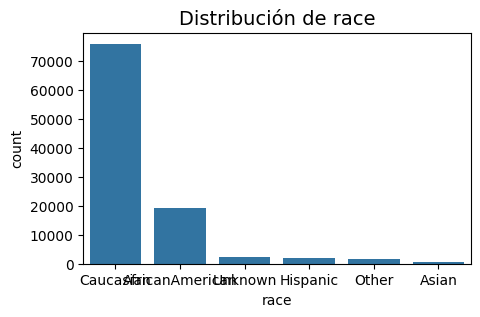



- Distribución de la variable categórica 'gender':
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         Female
1         Female
2         Female
3           Male
4           Male
           ...  
101761      Male
101762    Female
101763      Male
101764    Female
101765      Male
Name: gender, Length: 101766, dtype: object>

- Frecuencia Relativa:
gender
Female             0.537586
Male               0.462384
Unknown/Invalid    0.000029
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         Female
1         Female
2         Female
3           Male
4           Male
           ...  
101761      Male
101762    Female
101763      Male
101764    Female
101765      Male
Name: gender, Length: 101766, dtype: object>

- Valores Únicos: 3


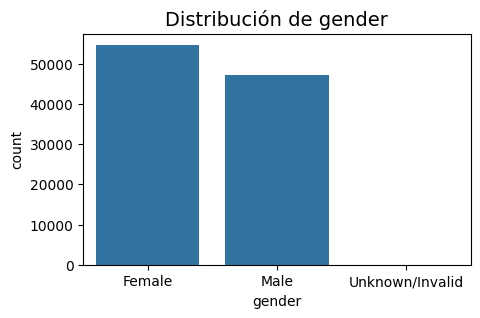



- Distribución de la variable categórica 'age':
age
Over_60_years          68541
30-60_years            30716
30_years_or_younger     2509
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         30_years_or_younger
1         30_years_or_younger
2         30_years_or_younger
3                 30-60_years
4                 30-60_years
                 ...         
101761          Over_60_years
101762          Over_60_years
101763          Over_60_years
101764          Over_60_years
101765          Over_60_years
Name: age, Length: 101766, dtype: object>

- Frecuencia Relativa:
age
Over_60_years          0.673516
30-60_years            0.301830
30_years_or_younger    0.024655
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         30_years_or_younger
1         30_years_or_younger
2         30_years_or_younger
3                 30-60_years
4                 30-60_years
                 ...         
10

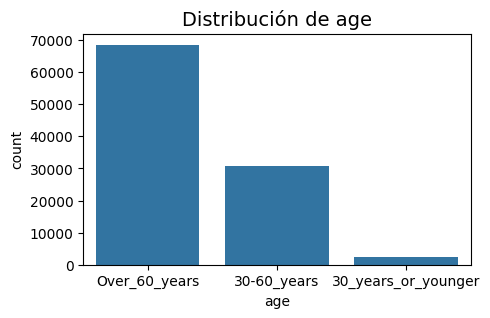



- Distribución de la variable categórica 'discharge_disposition_id':
discharge_disposition_id
Discharged_to_Home    60234
Other                 41532
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0                      Other
1         Discharged_to_Home
2         Discharged_to_Home
3         Discharged_to_Home
4         Discharged_to_Home
                 ...        
101761                 Other
101762                 Other
101763    Discharged_to_Home
101764                 Other
101765    Discharged_to_Home
Name: discharge_disposition_id, Length: 101766, dtype: object>

- Frecuencia Relativa:
discharge_disposition_id
Discharged_to_Home    0.591887
Other                 0.408113
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0                      Other
1         Discharged_to_Home
2         Discharged_to_Home
3         Discharged_to_Home
4         Discharged_to_Home
                 ...        


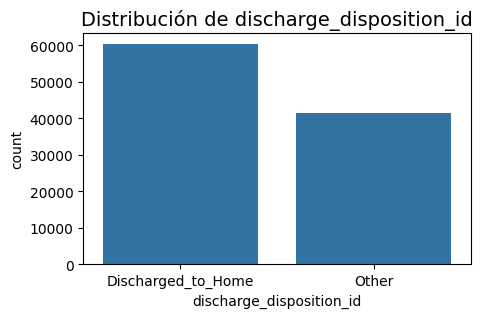



- Distribución de la variable categórica 'admission_source_id':
admission_source_id
Emergency    57494
Referral     30856
Other        13416
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0          Referral
1         Emergency
2         Emergency
3         Emergency
4         Emergency
            ...    
101761    Emergency
101762        Other
101763    Emergency
101764    Emergency
101765    Emergency
Name: admission_source_id, Length: 101766, dtype: object>

- Frecuencia Relativa:
admission_source_id
Emergency    0.564963
Referral     0.303205
Other        0.131832
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0          Referral
1         Emergency
2         Emergency
3         Emergency
4         Emergency
            ...    
101761    Emergency
101762        Other
101763    Emergency
101764    Emergency
101765    Emergency
Name: admission_source_id, Length: 101766, dtype: object>

- Valores

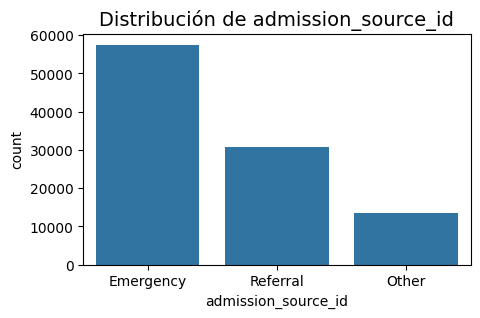



- Distribución de la variable categórica 'medical_specialty':
medical_specialty
Missing                   49949
Other                     16825
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0           Other
1         Missing
2         Missing
3         Missing
4         Missing
           ...   
101761    Missing
101762    Missing
101763    Missing
101764      Other
101765    Missing
Name: medical_specialty, Length: 101766, dtype: object>

- Frecuencia Relativa:
medical_specialty
Missing                   0.490822
Other                     0.165330
InternalMedicine          0.143810
Emergency/Trauma          0.074337
Family/GeneralPractice    0.073109
Cardiology                0.052591
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0           Other
1         Missing
2  

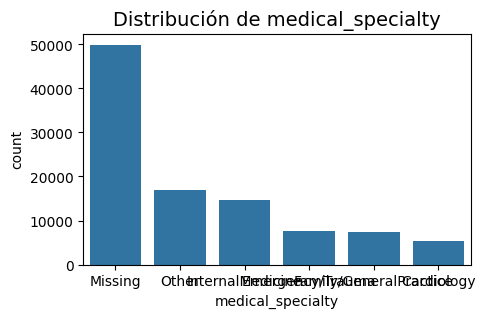



- Distribución de la variable categórica 'primary_diagnosis':
primary_diagnosis
Other                     68512
Respiratory_Issues        14423
Diabetes                   8757
Genitourinary_Issues       5117
Musculoskeletal_Issues     4957
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         Diabetes
1            Other
2            Other
3            Other
4            Other
            ...   
101761    Diabetes
101762       Other
101763       Other
101764       Other
101765       Other
Name: primary_diagnosis, Length: 101766, dtype: object>

- Frecuencia Relativa:
primary_diagnosis
Other                     0.673231
Respiratory_Issues        0.141727
Diabetes                  0.086050
Genitourinary_Issues      0.050282
Musculoskeletal_Issues    0.048710
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         Diabetes
1            Other
2            Other
3            Other
4            Other


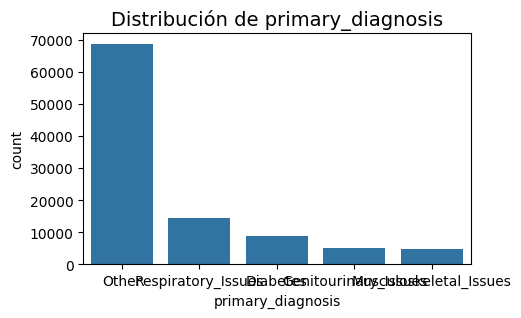



- Distribución de la variable categórica 'insulin':
insulin
No        47383
Steady    30849
Down      12218
Up        11316
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0             No
1             Up
2             No
3             Up
4         Steady
           ...  
101761      Down
101762    Steady
101763      Down
101764        Up
101765        No
Name: insulin, Length: 101766, dtype: object>

- Frecuencia Relativa:
insulin
No        0.465607
Steady    0.303137
Down      0.120060
Up        0.111196
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0             No
1             Up
2             No
3             Up
4         Steady
           ...  
101761      Down
101762    Steady
101763      Down
101764        Up
101765        No
Name: insulin, Length: 101766, dtype: object>

- Valores Únicos: 4


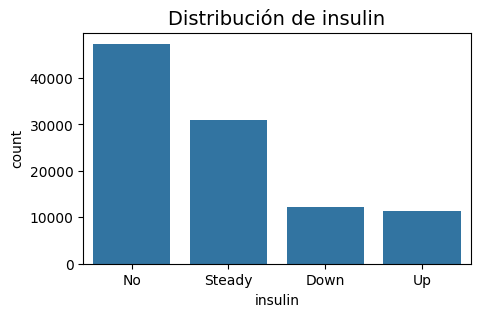



- Distribución de la variable categórica 'change':
change
No    54755
Ch    47011
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         No
1         Ch
2         No
3         Ch
4         Ch
          ..
101761    Ch
101762    No
101763    Ch
101764    Ch
101765    No
Name: change, Length: 101766, dtype: object>

- Frecuencia Relativa:
change
No    0.538048
Ch    0.461952
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         No
1         Ch
2         No
3         Ch
4         Ch
          ..
101761    Ch
101762    No
101763    Ch
101764    Ch
101765    No
Name: change, Length: 101766, dtype: object>

- Valores Únicos: 2


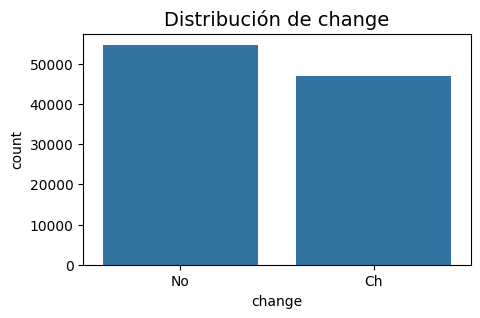



- Distribución de la variable categórica 'diabetesMed':
diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0          No
1         Yes
2         Yes
3         Yes
4         Yes
         ... 
101761    Yes
101762    Yes
101763    Yes
101764    Yes
101765     No
Name: diabetesMed, Length: 101766, dtype: object>

- Frecuencia Relativa:
diabetesMed
Yes    0.770031
No     0.229969
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0          No
1         Yes
2         Yes
3         Yes
4         Yes
         ... 
101761    Yes
101762    Yes
101763    Yes
101764    Yes
101765     No
Name: diabetesMed, Length: 101766, dtype: object>

- Valores Únicos: 2


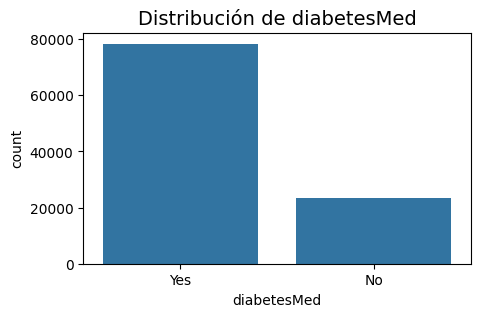



- Distribución de la variable categórica 'medicare':
medicare
False    69327
True     32439
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         False
1         False
2         False
3         False
4         False
          ...  
101761     True
101762     True
101763     True
101764     True
101765    False
Name: medicare, Length: 101766, dtype: object>

- Frecuencia Relativa:
medicare
False    0.681239
True     0.318761
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         False
1         False
2         False
3         False
4         False
          ...  
101761     True
101762     True
101763     True
101764     True
101765    False
Name: medicare, Length: 101766, dtype: object>

- Valores Únicos: 2


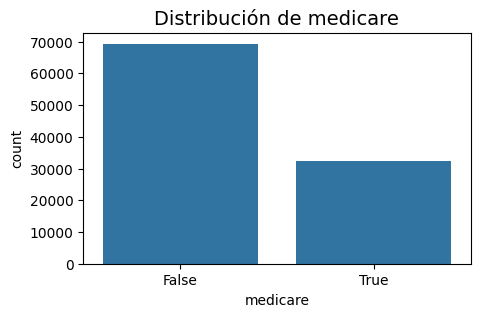



- Distribución de la variable categórica 'medicaid':
medicaid
False    98234
True      3532
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         False
1         False
2         False
3         False
4         False
          ...  
101761    False
101762    False
101763    False
101764    False
101765    False
Name: medicaid, Length: 101766, dtype: object>

- Frecuencia Relativa:
medicaid
False    0.965293
True     0.034707
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         False
1         False
2         False
3         False
4         False
          ...  
101761    False
101762    False
101763    False
101764    False
101765    False
Name: medicaid, Length: 101766, dtype: object>

- Valores Únicos: 2


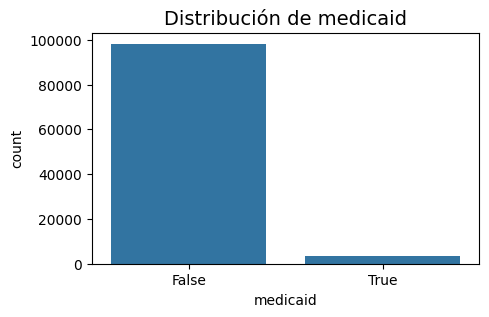



- Distribución de la variable categórica 'had_emergency':
had_emergency
False    90383
True     11383
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         False
1         False
2         False
3         False
4         False
          ...  
101761    False
101762    False
101763    False
101764    False
101765    False
Name: had_emergency, Length: 101766, dtype: object>

- Frecuencia Relativa:
had_emergency
False    0.888145
True     0.111855
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         False
1         False
2         False
3         False
4         False
          ...  
101761    False
101762    False
101763    False
101764    False
101765    False
Name: had_emergency, Length: 101766, dtype: object>

- Valores Únicos: 2


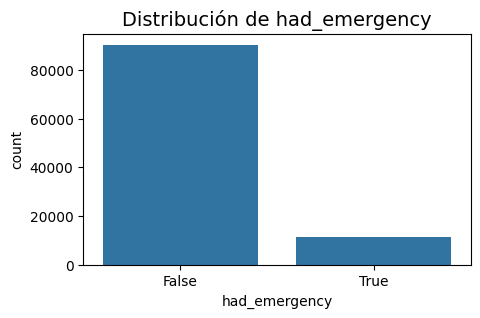



- Distribución de la variable categórica 'had_inpatient_days':
had_inpatient_days
False    67630
True     34136
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         False
1         False
2          True
3         False
4         False
          ...  
101761    False
101762     True
101763    False
101764     True
101765    False
Name: had_inpatient_days, Length: 101766, dtype: object>

- Frecuencia Relativa:
had_inpatient_days
False    0.664564
True     0.335436
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         False
1         False
2          True
3         False
4         False
          ...  
101761    False
101762     True
101763    False
101764     True
101765    False
Name: had_inpatient_days, Length: 101766, dtype: object>

- Valores Únicos: 2


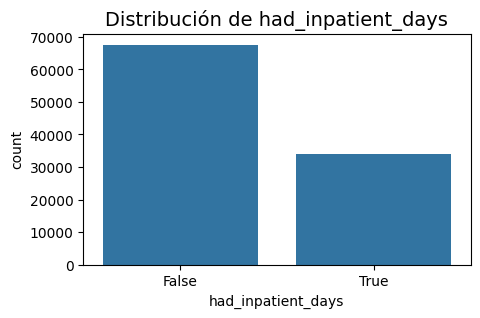



- Distribución de la variable categórica 'had_outpatient_days':
had_outpatient_days
False    85027
True     16739
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         False
1         False
2          True
3         False
4         False
          ...  
101761    False
101762    False
101763     True
101764    False
101765    False
Name: had_outpatient_days, Length: 101766, dtype: object>

- Frecuencia Relativa:
had_outpatient_days
False    0.835515
True     0.164485
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         False
1         False
2          True
3         False
4         False
          ...  
101761    False
101762    False
101763     True
101764    False
101765    False
Name: had_outpatient_days, Length: 101766, dtype: object>

- Valores Únicos: 2


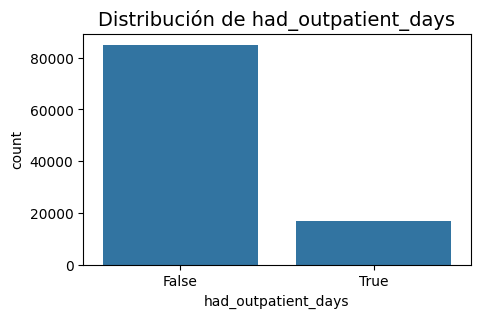



- Distribución de la variable categórica 'readmit_30_days':
readmit_30_days
False    90409
True     11357
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         False
1         False
2         False
3         False
4         False
          ...  
101761    False
101762    False
101763    False
101764    False
101765    False
Name: readmit_30_days, Length: 101766, dtype: object>

- Frecuencia Relativa:
readmit_30_days
False    0.888401
True     0.111599
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         False
1         False
2         False
3         False
4         False
          ...  
101761    False
101762    False
101763    False
101764    False
101765    False
Name: readmit_30_days, Length: 101766, dtype: object>

- Valores Únicos: 2


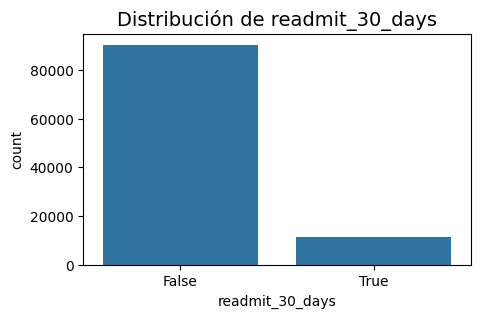

In [175]:
# We create a list containing the non-numeric variables:

non_numeric_vars = df.select_dtypes(exclude=['number']).columns

# We display the list:

print("List of non-numeric variables:\n")
print(non_numeric_vars)

# We iterate through the categorical variables and display their distribution, data type, absolute and relative frequency, mode, unique values, and a bar chart ordered by relative frequency:

for var in non_numeric_vars:
    print(f"\n\n- Distribución de la variable categórica '{var}':")
    print(df[var].value_counts())
    print(f"\n- Tipo: {df[var].dtype}")
    print(f"\n- Frecuencia Absoluta:\n{df[var].value_counts}")
    print(f"\n- Frecuencia Relativa:\n{df[var].value_counts(normalize = True)}")
    print(f"\n- Moda:\n{df[var].mode}")
    print(f"\n- Valores Únicos: {df[var].nunique()}")
    plt.figure (figsize = (5, 3))
    sns.countplot(x=var, data=df, order=df[var].value_counts().index)
    plt.title(f'Distribución de {var}', fontsize = 14)
    plt.show()


#### 3.2.3.- Removal of Categorical Variables with Practically a Single Value

In [176]:
# As we observed, some variables practically contain a single dominant value (95% of the values belong to a single category), and since they do not provide significant information for our use case, we remove them:

threshold = 0.95

# We identify the variables to remove:

vars_to_drop = []

for col in non_numeric_vars:
    unique_vals = df[col].nunique(dropna=False)
    max_freq = df[col].value_counts(normalize=True, dropna=False).max()

    if unique_vals == 1:
        print(f"Variable '{col}' tiene un solo valor único. Se eliminará.")
        vars_to_drop.append(col)
    elif max_freq >= threshold:
        print(f"Variable '{col}' es casi constante ({max_freq*100:.2f}% del mismo valor). Se eliminará.")
        vars_to_drop.append(col)

# We create a new dataset without those columns:

df_clean = df.drop(columns=vars_to_drop)

# We print a summary:

print(f"\nRemoved variables: {vars_to_drop}")
print(f"New dataset created with {df_clean.shape[1]} columns and {df_clean.shape[0]} rows.")

Variable 'medicaid' es casi constante (96.53% del mismo valor). Se eliminará.

Removed variables: ['medicaid']
New dataset created with 20 columns and 101766 rows.


#### 3.2.4.- Removal of Rare Rows or Outliers

In [177]:
# We observed in the graphs that some variables contain very infrequent values. We define a threshold of 0.5% for removing rare rows, since they do not provide significant information for our analysis.

threshold = 0.005

df_filtered = df.copy()

for col in df_filtered.select_dtypes(exclude=['number']).columns:
    # Calculamos frecuencia relativa
    freq = df_filtered[col].value_counts(normalize=True, dropna=False)
    rare_categories = freq[freq < threshold].index.tolist()

    if rare_categories:
        print(f" En '{col}', se eliminarán filas con valores raros: {rare_categories}")
        df_filtered = df_filtered[~df_filtered[col].isin(rare_categories)]

# We print a summary:

print(f"\nDataset after removing rows with infrequent values:")
print(f"Remaining rows: {df_filtered.shape[0]}")
print(f"Columns: {df_filtered.shape[1]}")

 En 'gender', se eliminarán filas con valores raros: ['Unknown/Invalid']

Dataset after removing rows with infrequent values:
Remaining rows: 101763
Columns: 21


#### 3.2.5.- Grouping Infrequent Values in Categorical Variables

In [178]:
# We observed in the graphs that some variables contain infrequent values. We define a threshold of 2% for grouping infrequent rows in order to simplify the dataset without losing significant information.

threshold = 0.02

threshold = 0.02

# We create a copy of the DataFrame to avoid modifying the original:

df_grouped = df_filtered.copy()

# We iterate through the categorical columns:

for col in df_grouped.select_dtypes(exclude=['number']).columns:

    # We calculate the relative frequency:

    freq = df_grouped[col].value_counts(normalize=True)

   # We identify rare categories (less frequent than the threshold):

    rare_categories = freq[freq < threshold].index

    # We replace those categories with 'Others':

    df_grouped[col] = df_grouped[col].apply(lambda x: 'Others' if x in rare_categories else x)

   # We print a summary:

    if len(rare_categories) > 0:
        print(f"Columna '{col}': {len(rare_categories)} categorías agrupadas como 'Others'.")

# We print the final shape of the dataset:

print(f"\nDataset final con categorías poco frecuentes agrupadas.")
print(f"Filas: {df_grouped.shape[0]}, Columnas: {df_grouped.shape[1]}")

# We print the first rows of df_grouped:

df_grouped.head(5)


Columna 'race': 2 categorías agrupadas como 'Others'.

Dataset final con categorías poco frecuentes agrupadas.
Filas: 101763, Columnas: 21


,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,primary_diagnosis,number_diagnoses,insulin,change,diabetesMed,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days,readmit_30_days
0,Caucasian,Female,30_years_or_younger,Other,Referral,1,Other,41,0,1,Diabetes,1,No,No,No,False,False,False,False,False,False
1,Caucasian,Female,30_years_or_younger,Discharged_to_Home,Emergency,3,Missing,59,0,18,Other,9,Up,Ch,Yes,False,False,False,False,False,False
2,AfricanAmerican,Female,30_years_or_younger,Discharged_to_Home,Emergency,2,Missing,11,5,13,Other,6,No,No,Yes,False,False,False,True,True,False
3,Caucasian,Male,30-60_years,Discharged_to_Home,Emergency,2,Missing,44,1,16,Other,7,Up,Ch,Yes,False,False,False,False,False,False
4,Caucasian,Male,30-60_years,Discharged_to_Home,Emergency,1,Missing,51,0,8,Other,5,Steady,Ch,Yes,False,False,False,False,False,False


#### 3.2.6.- Conversion to Boolean Variables

In [179]:
# We identify the variables that only contain 2 values (binary categorical variables):

binary_df_grouped = [col for col in df_grouped if df[col].nunique(dropna=False) == 2]

# We display the result:

print('Non-numeric variables with only 2 unique values:')
for col in binary_df_grouped:
    print(f"- {col}: {df[col].unique()}")


Non-numeric variables with only 2 unique values:
- discharge_disposition_id: ['Other' 'Discharged_to_Home']
- change: ['No' 'Ch']
- diabetesMed: ['No' 'Yes']
- medicare: ['False' 'True']
- medicaid: ['False' 'True']
- had_emergency: ['False' 'True']
- had_inpatient_days: ['False' 'True']
- had_outpatient_days: ['False' 'True']
- readmit_30_days: ['False' 'True']


In [180]:
# We convert each binary variable to Boolean format:

for col in binary_df_grouped:
    unique_vals = df[col].dropna().unique()
    if len(unique_vals) == 2:
        true_val = unique_vals[0]
        false_val = unique_vals[1]
        df_grouped[col] = df_grouped[col].map({true_val: True, false_val: False})

# We check the change:

print("\nVariables converted to Boolean format:")
print(df[binary_df_grouped].head())



Variables converted to Boolean format:
  discharge_disposition_id change diabetesMed medicare medicaid had_emergency  \
0                    Other     No          No    False    False         False   
1       Discharged_to_Home     Ch         Yes    False    False         False   
2       Discharged_to_Home     No         Yes    False    False         False   
3       Discharged_to_Home     Ch         Yes    False    False         False   
4       Discharged_to_Home     Ch         Yes    False    False         False   

  had_inpatient_days had_outpatient_days readmit_30_days  
0              False               False           False  
1              False               False           False  
2               True                True           False  
3              False               False           False  
4              False               False           False  


#### 3.2.7.- Analysis of Categorical Variables After "Cleaning" the DataFrame



Distribución de la variable categórica 'race':
race
Caucasian          76099
AfricanAmerican    19210
Unknown             2271
Others              2146
Hispanic            2037
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
race
Caucasian          76099
AfricanAmerican    19210
Unknown             2271
Others              2146
Hispanic            2037
Name: count, dtype: int64

- Frecuencia Relativa:
race
Caucasian          0.747806
AfricanAmerican    0.188772
Unknown            0.022317
Others             0.021088
Hispanic           0.020017
Name: proportion, dtype: float64

- Moda: Caucasian

- Valores Únicos: 5


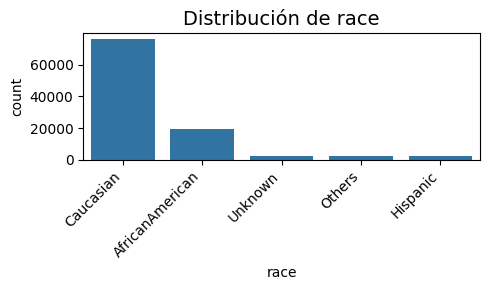



Distribución de la variable categórica 'gender':
gender
Female    54708
Male      47055
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
gender
Female    54708
Male      47055
Name: count, dtype: int64

- Frecuencia Relativa:
gender
Female    0.537602
Male      0.462398
Name: proportion, dtype: float64

- Moda: Female

- Valores Únicos: 2


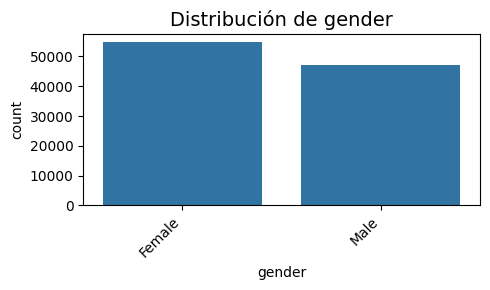



Distribución de la variable categórica 'age':
age
Over_60_years          68538
30-60_years            30716
30_years_or_younger     2509
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
age
Over_60_years          68538
30-60_years            30716
30_years_or_younger     2509
Name: count, dtype: int64

- Frecuencia Relativa:
age
Over_60_years          0.673506
30-60_years            0.301839
30_years_or_younger    0.024655
Name: proportion, dtype: float64

- Moda: Over_60_years

- Valores Únicos: 3


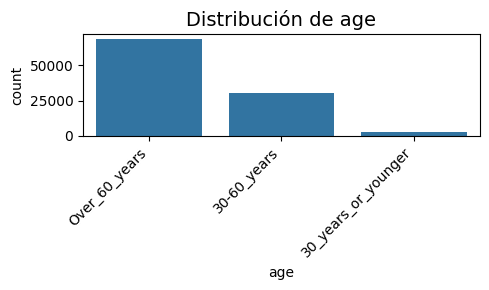



Distribución de la variable categórica 'discharge_disposition_id':
discharge_disposition_id
False    60232
True     41531
Name: count, dtype: int64

- Tipo: bool

- Frecuencia Absoluta:
discharge_disposition_id
False    60232
True     41531
Name: count, dtype: int64

- Frecuencia Relativa:
discharge_disposition_id
False    0.591885
True     0.408115
Name: proportion, dtype: float64

- Moda: False

- Valores Únicos: 2


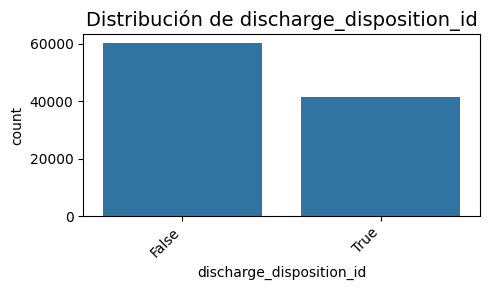



Distribución de la variable categórica 'admission_source_id':
admission_source_id
Emergency    57492
Referral     30855
Other        13416
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
admission_source_id
Emergency    57492
Referral     30855
Other        13416
Name: count, dtype: int64

- Frecuencia Relativa:
admission_source_id
Emergency    0.564960
Referral     0.303205
Other        0.131836
Name: proportion, dtype: float64

- Moda: Emergency

- Valores Únicos: 3


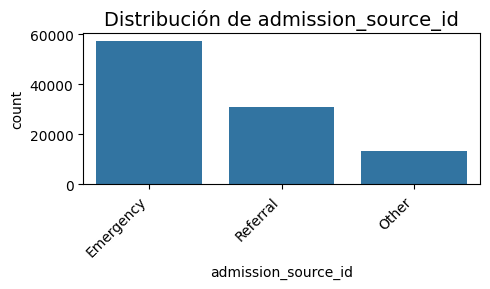



Distribución de la variable categórica 'medical_specialty':
medical_specialty
Missing                   49947
Other                     16825
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5351
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
medical_specialty
Missing                   49947
Other                     16825
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5351
Name: count, dtype: int64

- Frecuencia Relativa:
medical_specialty
Missing                   0.490817
Other                     0.165335
InternalMedicine          0.143815
Emergency/Trauma          0.074339
Family/GeneralPractice    0.073111
Cardiology                0.052583
Name: proportion, dtype: float64

- Moda: Missing

- Valores Únicos: 6


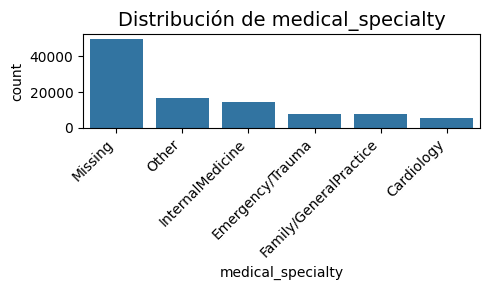



Distribución de la variable categórica 'primary_diagnosis':
primary_diagnosis
Other                     68509
Respiratory_Issues        14423
Diabetes                   8757
Genitourinary_Issues       5117
Musculoskeletal_Issues     4957
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
primary_diagnosis
Other                     68509
Respiratory_Issues        14423
Diabetes                   8757
Genitourinary_Issues       5117
Musculoskeletal_Issues     4957
Name: count, dtype: int64

- Frecuencia Relativa:
primary_diagnosis
Other                     0.673221
Respiratory_Issues        0.141731
Diabetes                  0.086053
Genitourinary_Issues      0.050284
Musculoskeletal_Issues    0.048711
Name: proportion, dtype: float64

- Moda: Other

- Valores Únicos: 5


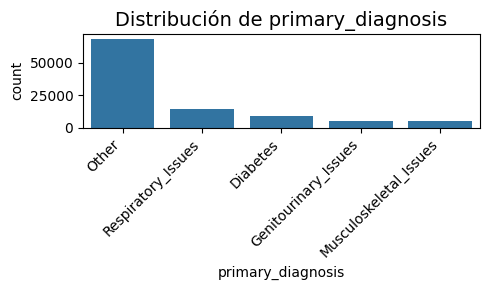



Distribución de la variable categórica 'insulin':
insulin
No        47380
Steady    30849
Down      12218
Up        11316
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
insulin
No        47380
Steady    30849
Down      12218
Up        11316
Name: count, dtype: int64

- Frecuencia Relativa:
insulin
No        0.465592
Steady    0.303146
Down      0.120063
Up        0.111200
Name: proportion, dtype: float64

- Moda: No

- Valores Únicos: 4


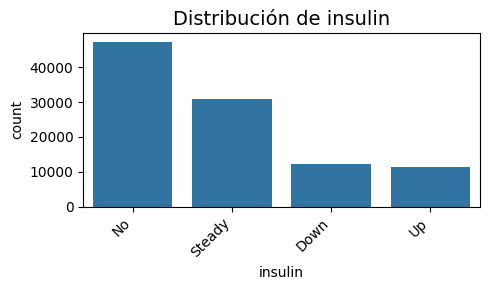



Distribución de la variable categórica 'change':
change
True     54754
False    47009
Name: count, dtype: int64

- Tipo: bool

- Frecuencia Absoluta:
change
True     54754
False    47009
Name: count, dtype: int64

- Frecuencia Relativa:
change
True     0.538054
False    0.461946
Name: proportion, dtype: float64

- Moda: True

- Valores Únicos: 2


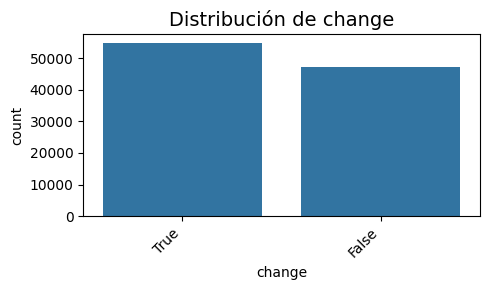



Distribución de la variable categórica 'diabetesMed':
diabetesMed
False    78361
True     23402
Name: count, dtype: int64

- Tipo: bool

- Frecuencia Absoluta:
diabetesMed
False    78361
True     23402
Name: count, dtype: int64

- Frecuencia Relativa:
diabetesMed
False    0.770034
True     0.229966
Name: proportion, dtype: float64

- Moda: False

- Valores Únicos: 2


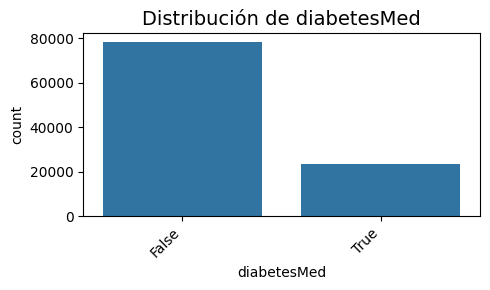



Distribución de la variable categórica 'medicare':
medicare
True     69324
False    32439
Name: count, dtype: int64

- Tipo: bool

- Frecuencia Absoluta:
medicare
True     69324
False    32439
Name: count, dtype: int64

- Frecuencia Relativa:
medicare
True     0.68123
False    0.31877
Name: proportion, dtype: float64

- Moda: True

- Valores Únicos: 2


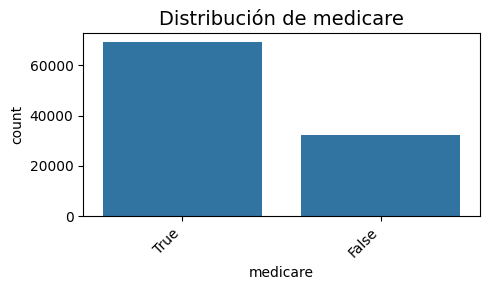



Distribución de la variable categórica 'medicaid':
medicaid
True     98231
False     3532
Name: count, dtype: int64

- Tipo: bool

- Frecuencia Absoluta:
medicaid
True     98231
False     3532
Name: count, dtype: int64

- Frecuencia Relativa:
medicaid
True     0.965292
False    0.034708
Name: proportion, dtype: float64

- Moda: True

- Valores Únicos: 2


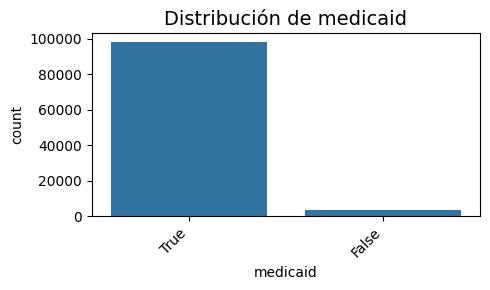



Distribución de la variable categórica 'had_emergency':
had_emergency
True     90380
False    11383
Name: count, dtype: int64

- Tipo: bool

- Frecuencia Absoluta:
had_emergency
True     90380
False    11383
Name: count, dtype: int64

- Frecuencia Relativa:
had_emergency
True     0.888142
False    0.111858
Name: proportion, dtype: float64

- Moda: True

- Valores Únicos: 2


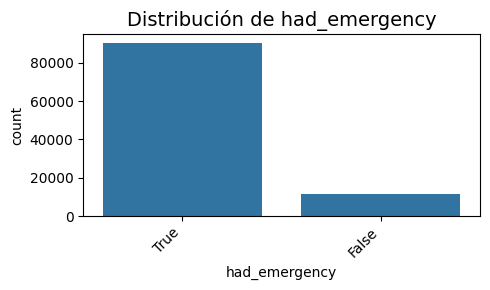



Distribución de la variable categórica 'had_inpatient_days':
had_inpatient_days
True     67627
False    34136
Name: count, dtype: int64

- Tipo: bool

- Frecuencia Absoluta:
had_inpatient_days
True     67627
False    34136
Name: count, dtype: int64

- Frecuencia Relativa:
had_inpatient_days
True     0.664554
False    0.335446
Name: proportion, dtype: float64

- Moda: True

- Valores Únicos: 2


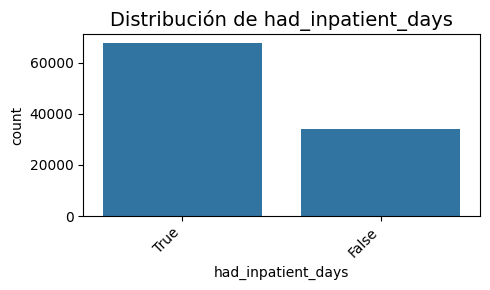



Distribución de la variable categórica 'had_outpatient_days':
had_outpatient_days
True     85024
False    16739
Name: count, dtype: int64

- Tipo: bool

- Frecuencia Absoluta:
had_outpatient_days
True     85024
False    16739
Name: count, dtype: int64

- Frecuencia Relativa:
had_outpatient_days
True     0.83551
False    0.16449
Name: proportion, dtype: float64

- Moda: True

- Valores Únicos: 2


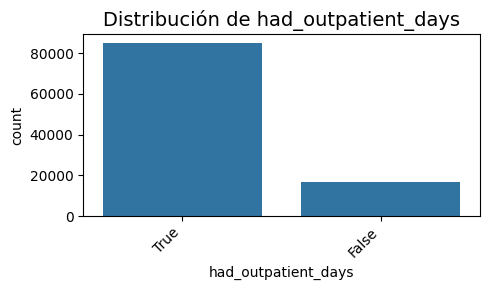



Distribución de la variable categórica 'readmit_30_days':
readmit_30_days
True     90406
False    11357
Name: count, dtype: int64

- Tipo: bool

- Frecuencia Absoluta:
readmit_30_days
True     90406
False    11357
Name: count, dtype: int64

- Frecuencia Relativa:
readmit_30_days
True     0.888398
False    0.111602
Name: proportion, dtype: float64

- Moda: True

- Valores Únicos: 2


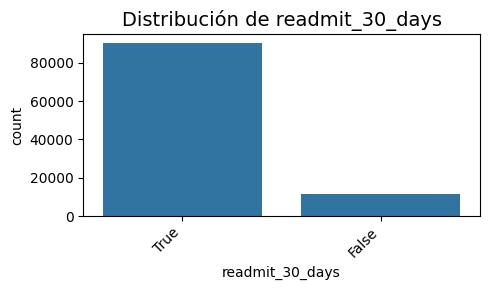

In [181]:
# We iterate once again through the categorical variables after all preprocessing steps and display their distribution, type, absolute and relative frequency,
# mode, unique values, and a bar chart ordered by relative frequency:

cat_cols = df_grouped.select_dtypes(exclude='number').columns

for var in cat_cols:
    print(f"\n\nDistribución de la variable categórica '{var}':")

    # Frequency statistics:

    print(df_grouped[var].value_counts())
    print(f"\n- Tipo: {df_grouped[var].dtype}")
    print(f"\n- Frecuencia Absoluta:\n{df_grouped[var].value_counts()}")
    print(f"\n- Frecuencia Relativa:\n{df_grouped[var].value_counts(normalize=True)}")
    print(f"\n- Moda: {df_grouped[var].mode()[0]}")
    print(f"\n- Valores Únicos: {df_grouped[var].nunique()}")

    # Bar plots:

    plt.figure(figsize=(5, 3))
    sns.countplot(x=var, data=df_grouped, order=df_grouped[var].value_counts().index)
    plt.title(f'Distribución de {var}', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


From the graphs and data, we observe that we have retained only the variables capable of providing useful information for the analysis, while the least significant values have been removed or grouped. Converting binary variables to Boolean format will also facilitate future processing.

### 3.3.- Analysis and Processing of Numerical Variables

We now study each numerical variable, observe its distribution, and discuss the presence of outliers as well as the best way to handle them in each case.

#### 3.3.1.- Analysis of Numerical Variables

In [182]:
# List of numerical variables:

numeric_var = df_grouped.select_dtypes(include='number').columns

print("Numerical variables to analyze:")
print(numeric_var)


Numerical variables to analyze:
Index(['time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_diagnoses'],
      dtype='object')



Análisis de la variable numérica: 'time_in_hospital'
--------------------------------------------------
Media: 4.3960
Mediana: 4.0000
Varianza: 8.9108
Desviación Típica: 2.9851
IQR (Rango Intercuartílico): 4.0000


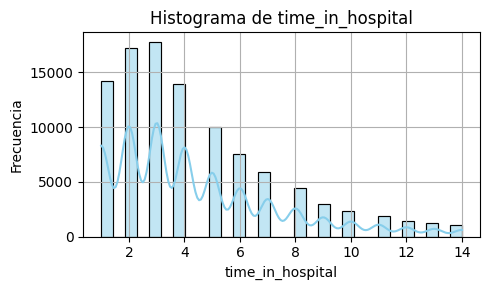

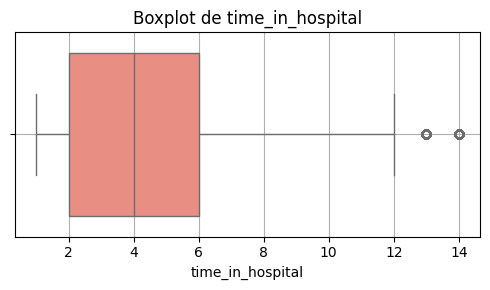


Análisis de la variable numérica: 'num_lab_procedures'
--------------------------------------------------
Media: 43.0959
Mediana: 44.0000
Varianza: 387.0749
Desviación Típica: 19.6742
IQR (Rango Intercuartílico): 26.0000


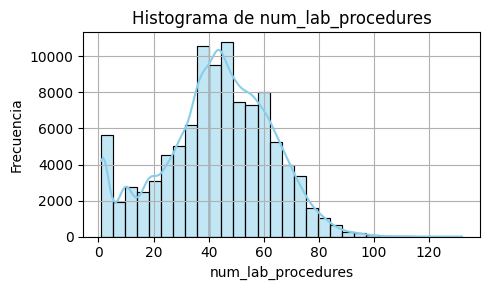

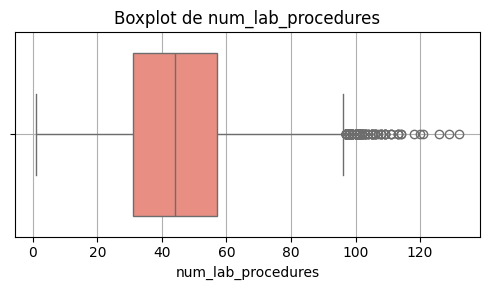


Análisis de la variable numérica: 'num_procedures'
--------------------------------------------------
Media: 1.3397
Mediana: 1.0000
Varianza: 2.9097
Desviación Típica: 1.7058
IQR (Rango Intercuartílico): 2.0000


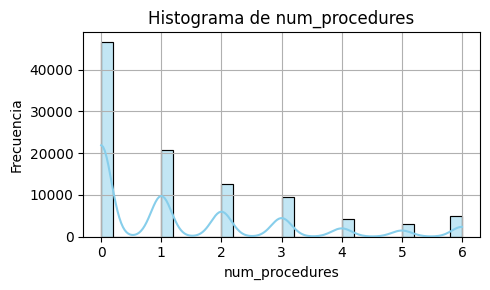

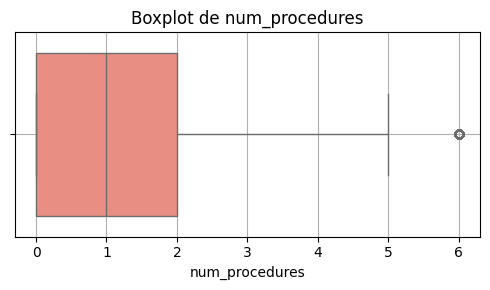


Análisis de la variable numérica: 'num_medications'
--------------------------------------------------
Media: 16.0218
Mediana: 15.0000
Varianza: 66.0577
Desviación Típica: 8.1276
IQR (Rango Intercuartílico): 10.0000


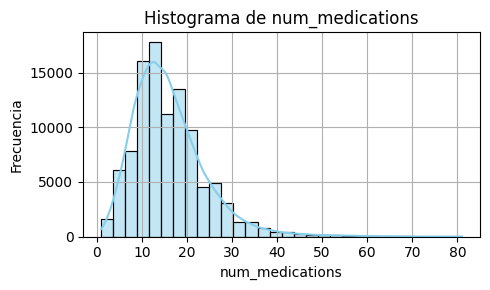

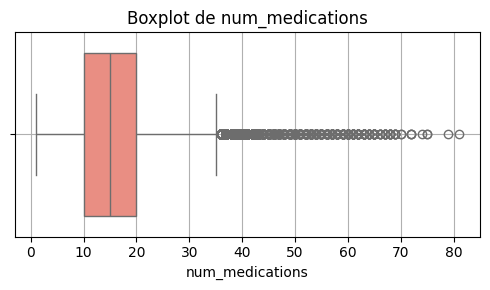


Análisis de la variable numérica: 'number_diagnoses'
--------------------------------------------------
Media: 7.4226
Mediana: 8.0000
Varianza: 3.7387
Desviación Típica: 1.9336
IQR (Rango Intercuartílico): 3.0000


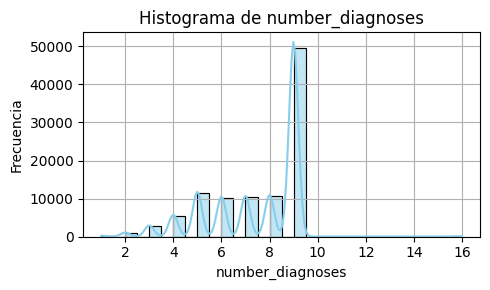

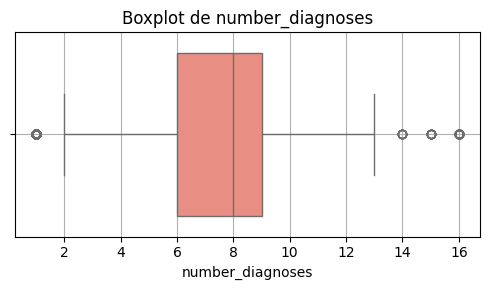

In [183]:
# We iterate through each numerical variable:

for col in numeric_var:
    print(f"\nAnálisis de la variable numérica: '{col}'")
    print("-" * 50)

    # Numerical Methods:

    mean = df_grouped[col].mean()
    median = df_grouped[col].median()
    variance = df_grouped[col].var()
    std_dev = df_grouped[col].std()
    Q1 = df_grouped[col].quantile(0.25)
    Q3 = df_grouped[col].quantile(0.75)
    IQR = Q3 - Q1

    print(f"Media: {mean:.4f}")
    print(f"Mediana: {median:.4f}")
    print(f"Varianza: {variance:.4f}")
    print(f"Desviación Típica: {std_dev:.4f}")
    print(f"IQR (Rango Intercuartílico): {IQR:.4f}")

    # Graphical Methods: Histogram:

    plt.figure(figsize=(5, 3))
    sns.histplot(df_grouped[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Graphical Methods: Boxplot:

    plt.figure(figsize=(5, 3))
    sns.boxplot(x=df_grouped[col], color='salmon')
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


By observing the boxplots, we can see that there are many outliers.

#### 3.3.2.- Outlier Detection Using Tukey's Test

In [184]:
# Since we do not know the domain of the variables well enough nor the appropriate thresholds to apply, we will use this method to detect outliers.

# We calculate the lower and upper limits for outliers:

for col in numeric_var:

    Q1 = df_grouped[col].quantile(0.25)
    Q3 = df_grouped[col].quantile(0.75)
    IQR = Q3 - Q1
    inferior = Q1 - 1.5 * IQR
    superior = Q3 + 1.5 * IQR

    # We calculate the Outliers:

    outliers = df_grouped[(df_grouped[col] < inferior) | (df_grouped[col] > superior)]

    # We print how many outliers each variable contains::

    num_outliers = outliers.shape[0]
    print(f"- {col}: {num_outliers} outliers")

- time_in_hospital: 2252 outliers
- num_lab_procedures: 143 outliers
- num_procedures: 4954 outliers
- num_medications: 2557 outliers
- number_diagnoses: 281 outliers


### 3.3.4.- Outlier Treatment

In [185]:
# Since there are many outliers and we do not know the importance of the information they provide, we will impute them using the value of the third quartile plus 1.5 times
# the interquartile range:

for col in numeric_var:
    Q1 = df_grouped[col].quantile(0.25)
    Q3 = df_grouped[col].quantile(0.75)
    IQR = Q3 - Q1
    inferior = Q1 - 1.5 * IQR
    superior = Q3 + 1.5 * IQR

    # We replace outliers with the limits and print the result:

    df_grouped[col] = df_grouped[col].apply(lambda x: inferior if x < inferior else (superior if x > superior else x))
    print(f"{col}: Outliers imputados con límites Tukey.")


time_in_hospital: Outliers imputados con límites Tukey.
num_lab_procedures: Outliers imputados con límites Tukey.
num_procedures: Outliers imputados con límites Tukey.
num_medications: Outliers imputados con límites Tukey.
number_diagnoses: Outliers imputados con límites Tukey.



Análisis de la variable numérica: 'time_in_hospital'
--------------------------------------------------
Media: 4.3636
Mediana: 4.0000
Varianza: 8.3646
Desviación Típica: 2.8922
IQR (Rango Intercuartílico): 4.0000


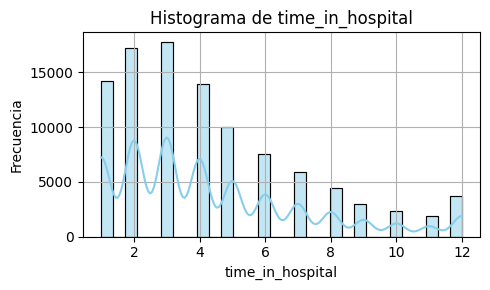

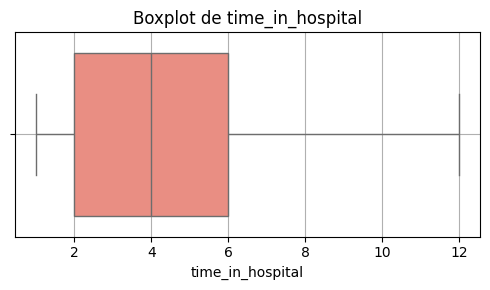


Análisis de la variable numérica: 'num_lab_procedures'
--------------------------------------------------
Media: 43.0875
Mediana: 44.0000
Varianza: 386.0742
Desviación Típica: 19.6488
IQR (Rango Intercuartílico): 26.0000


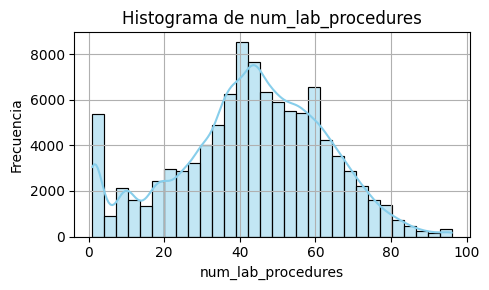

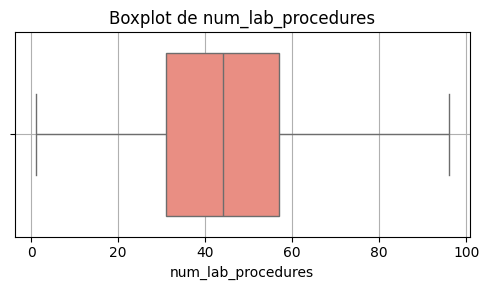


Análisis de la variable numérica: 'num_procedures'
--------------------------------------------------
Media: 1.2910
Mediana: 1.0000
Varianza: 2.5023
Desviación Típica: 1.5819
IQR (Rango Intercuartílico): 2.0000


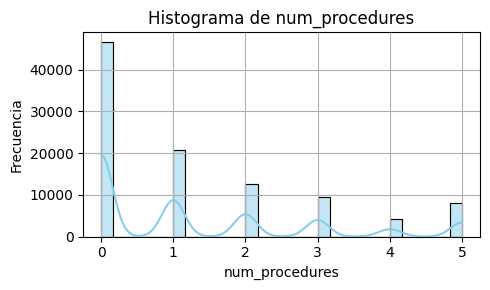

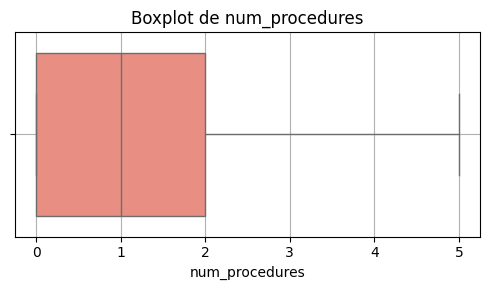


Análisis de la variable numérica: 'num_medications'
--------------------------------------------------
Media: 15.8085
Mediana: 15.0000
Varianza: 54.7104
Desviación Típica: 7.3966
IQR (Rango Intercuartílico): 10.0000


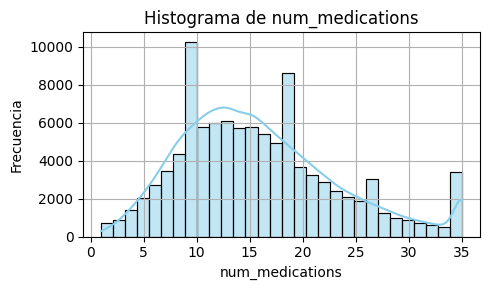

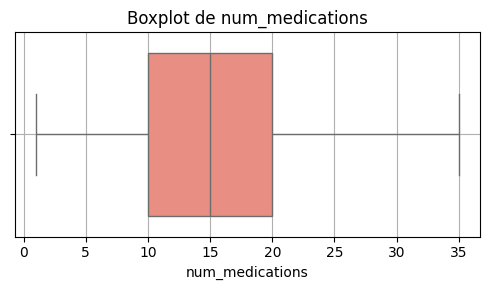


Análisis de la variable numérica: 'number_diagnoses'
--------------------------------------------------
Media: 7.4224
Mediana: 8.0000
Varianza: 3.7068
Desviación Típica: 1.9253
IQR (Rango Intercuartílico): 3.0000


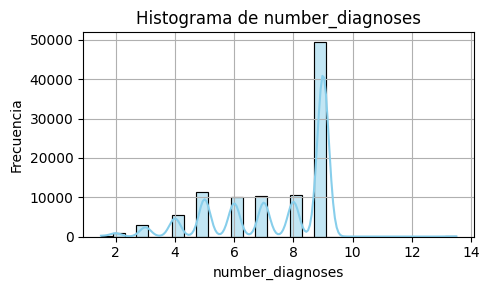

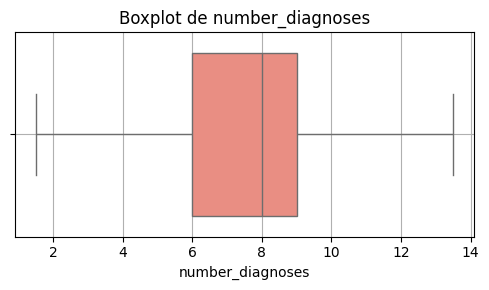

In [186]:
# We iterate again through each numerical variable after outlier imputation in order to observe the resulting distributions:

for col in numeric_var:
    print(f"\nAnálisis de la variable numérica: '{col}'")
    print("-" * 50)

    # Numerical Methods:

    mean = df_grouped[col].mean()
    median = df_grouped[col].median()
    variance = df_grouped[col].var()
    std_dev = df_grouped[col].std()
    Q1 = df_grouped[col].quantile(0.25)
    Q3 = df_grouped[col].quantile(0.75)
    IQR = Q3 - Q1

    print(f"Media: {mean:.4f}")
    print(f"Mediana: {median:.4f}")
    print(f"Varianza: {variance:.4f}")
    print(f"Desviación Típica: {std_dev:.4f}")
    print(f"IQR (Rango Intercuartílico): {IQR:.4f}")

    # Graphical Methods: Histogram

    plt.figure(figsize=(5, 3))
    sns.histplot(df_grouped[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Graphical Methods: Boxplot:

    plt.figure(figsize=(5, 3))
    sns.boxplot(x=df_grouped[col], color='salmon')
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## 4.- Multivariate Analysis

Once the univariate analysis has been completed, it is time to perform the bivariate analysis. We will study how the variables behave in relation to one another. We are especially interested in the relationship between the variables and the target variable.

### 4.1.- Numerical vs Numerical

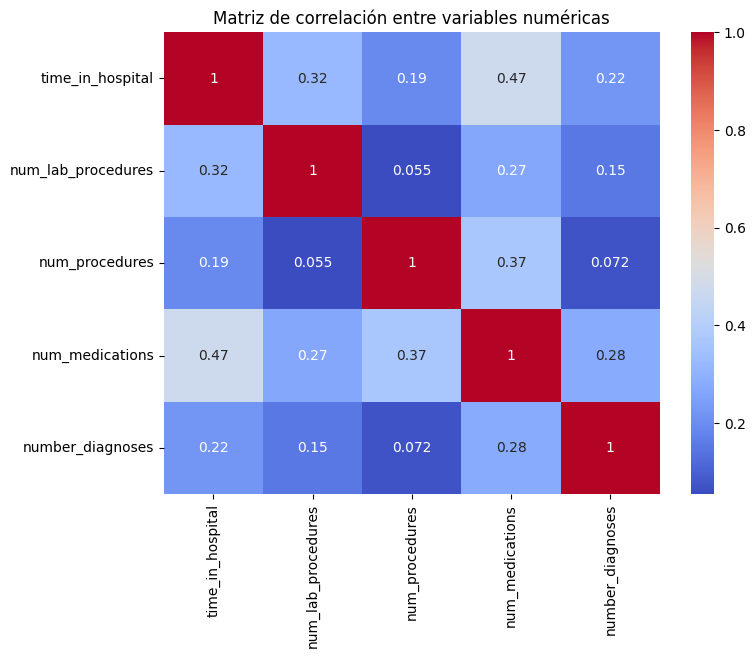

In [187]:
# We select the numerical variables:

numeric_vars = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses']

# We calculate the correlation matrix:

corr_matrix = df_grouped[numeric_vars].corr()

# We display the correlation matrix using a heatmap:

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación entre variables numéricas')
plt.show()


We can observe that there are no pairs of numerical variables with high correlation (the maximum value is 0.47, which represents a moderate correlation and is not high enough to discard any variable).

### 4.2.- Numerical vs Categorical

At this stage, the main objective is to compare each numerical variable against the target variable and determine whether they have any relationship with the probability of readmission.

##### Boxplots

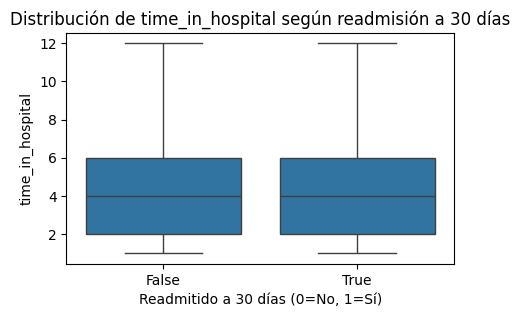

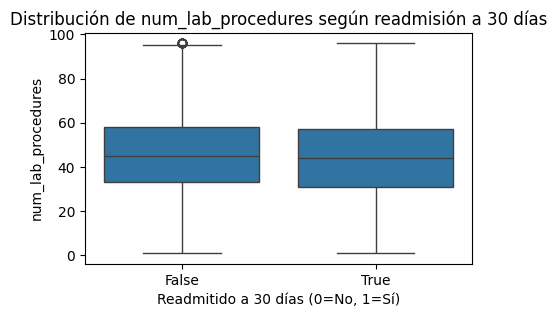

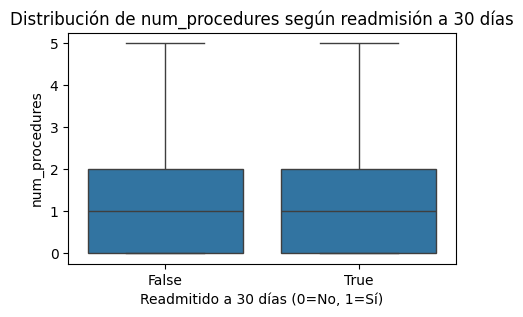

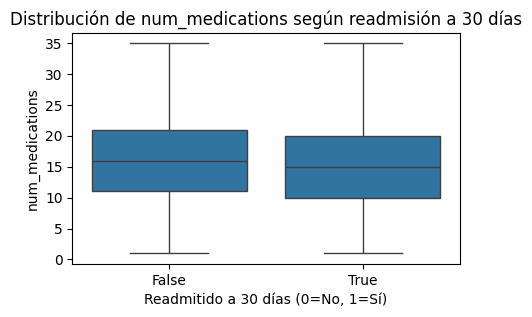

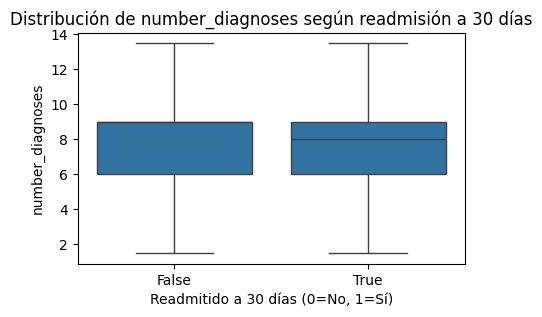

In [188]:
# We visually compare each numerical variable with the target variable readmit_30_days using boxplots:

for col in numeric_vars:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x='readmit_30_days', y=col, data=df_grouped)
    plt.title(f'Distribución de {col} según readmisión a 30 días')
    plt.xlabel('Readmitido a 30 días (0=No, 1=Sí)')
    plt.ylabel(col)
    plt.show()

The boxes, whiskers, and median values demonstrate that the only numerical variable that may be correlated with the target variable is number_diagnoses. Since number_diagnoses does not follow a normal distribution, we will apply non-parametric statistical tests.

##### Kruskal-Wallis Test and Mann-Whitney Test with number_diagnoses

In [189]:
grupos = [df[df['readmit_30_days'] == val]['number_diagnoses'] for val in df['readmit_30_days'].unique()]

stat, p = kruskal(*grupos)

print("Test de Kruskal-Wallis")
print("Estadístico H:", stat)
print("P-valor:", p)
if p < 0.05:
    print("There is a significant difference in number_diagnoses between readmitted and non-readmitted patients.")
else:
    print("There is NO significant difference in number_diagnoses between readmitted and non-readmitted patients.")

Test de Kruskal-Wallis
Estadístico H: 227.00842979034525
P-valor: 2.6777644509839195e-51
There is a significant difference in number_diagnoses between readmitted and non-readmitted patients.


H = 227.01 is a very high value, indicating a large difference in the distribution of number_diagnoses between readmitted and non-readmitted patient groups.

The p-value is 2.68e-51, practically zero and far below 0.05, meaning that we can reject the null hypothesis and conclude that there are statistically significant differences between the groups.

In [190]:
# Groups according to readmit_30_days:

group_no_readmit = df[df['readmit_30_days'] == False]['number_diagnoses']
group_readmit = df[df['readmit_30_days'] == True]['number_diagnoses']

stat, p = mannwhitneyu(group_no_readmit, group_readmit, alternative='two-sided')

print("Test Mann-Whitney U")
print("U statistic:", stat)
print("P-value:", p)
if p < 0.05:
    print("There is a significant difference in number_diagnoses between readmitted and non-readmitted patients.")
else:
    print("There is NO significant difference in number_diagnoses between readmitted and non-readmitted patients.")

Test Mann-Whitney U
U statistic: nan
P-value: nan
There is NO significant difference in number_diagnoses between readmitted and non-readmitted patients.


/tmp/ipykernel_7395/2955722636.py:6: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(group_no_readmit, group_readmit, alternative='two-sided')


The U statistic is very high and the p-value is almost zero, far below 0.05, allowing us to reject the null hypothesis and once again verify that there is a relationship between the variables.

### Categorical vs Categorical

As with the numerical variables, we analyze the behavior of each categorical variable with respect to the target variable. We will use Chi-Square tests and contingency tables.

##### Contingency Tables

In [191]:
# We select the categorical variables:

categorical = ['race', 'gender', 'age', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty', 'insulin', 'change', 'diabetesMed', 'medicare', 'had_emergency',
               'had_inpatient_days', 'had_outpatient_days']

for var in categorical:
    print(f"Row-normalized table with totals for '{var}':")
    tabla = pd.crosstab(df[var], df_grouped['readmit_30_days'], normalize='index', margins=True)
    print(tabla)
    print("\n" + "-"*60 + "\n")

Row-normalized table with totals for 'race':
readmit_30_days     False      True
race                               
AfricanAmerican  0.112181  0.887819
Asian            0.101404  0.898596
Caucasian        0.112906  0.887094
Hispanic         0.104075  0.895925
Other            0.096346  0.903654
Unknown          0.082783  0.917217
All              0.111602  0.888398

------------------------------------------------------------

Row-normalized table with totals for 'gender':
readmit_30_days     False      True
gender                             
Female           0.112452  0.887548
Male             0.110615  0.889385
All              0.111602  0.888398

------------------------------------------------------------

Row-normalized table with totals for 'age':
readmit_30_days         False      True
age                                    
30-60_years          0.101543  0.898457
30_years_or_younger  0.111200  0.888800
Over_60_years        0.116125  0.883875
All                  0.111602  0.8

According to the previous results, the variables that could have the greatest influence on the target variable are: had_emergency, had_inpatient_days, discharge_disposition_id, and medical_specialty, among others.

##### Stacked Bar Charts

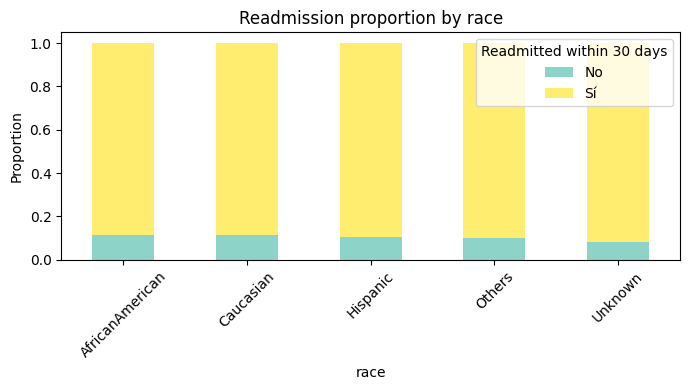

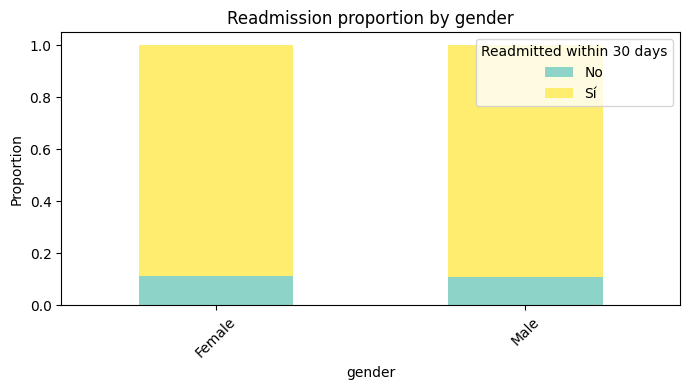

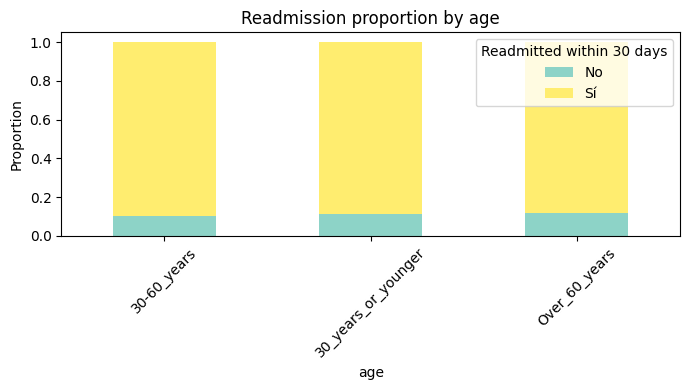

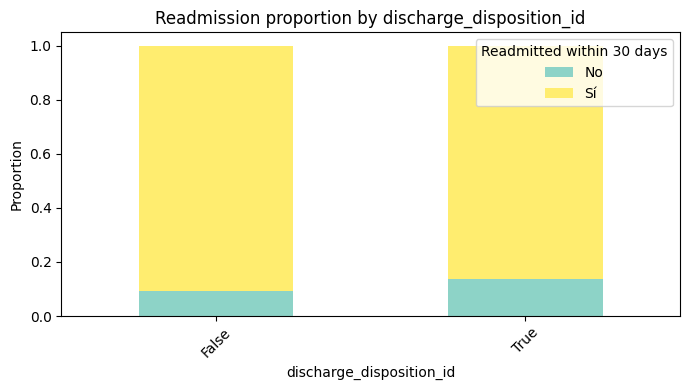

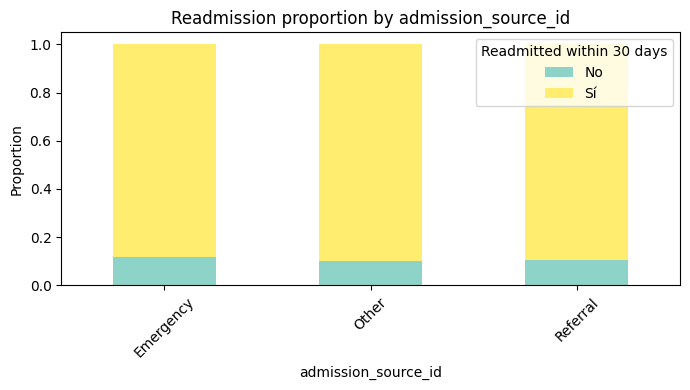

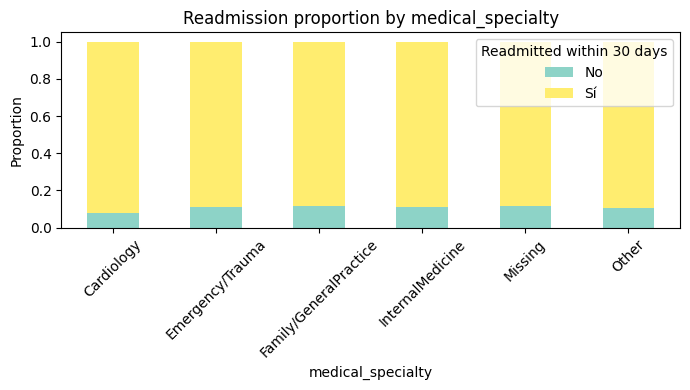

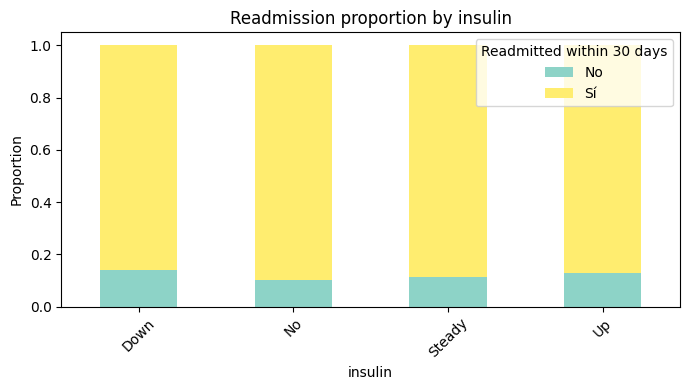

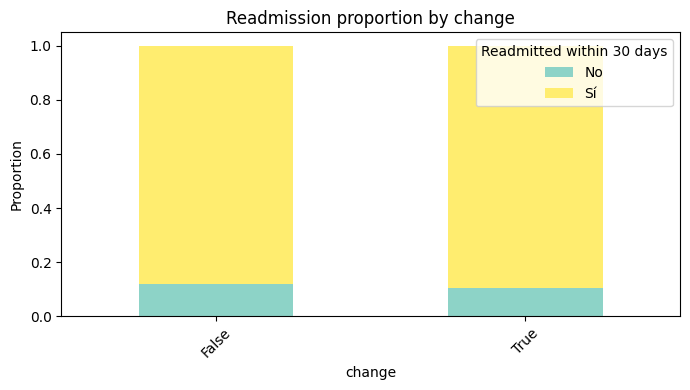

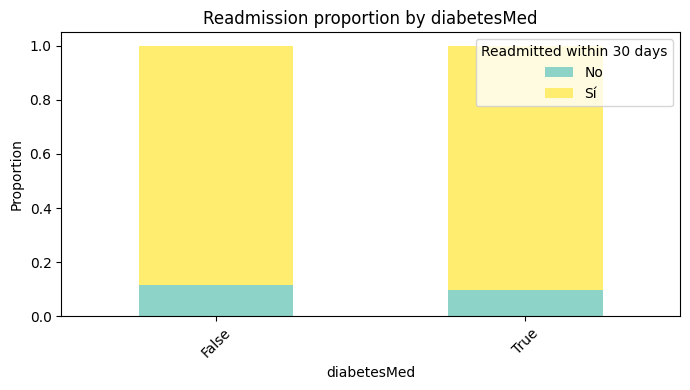

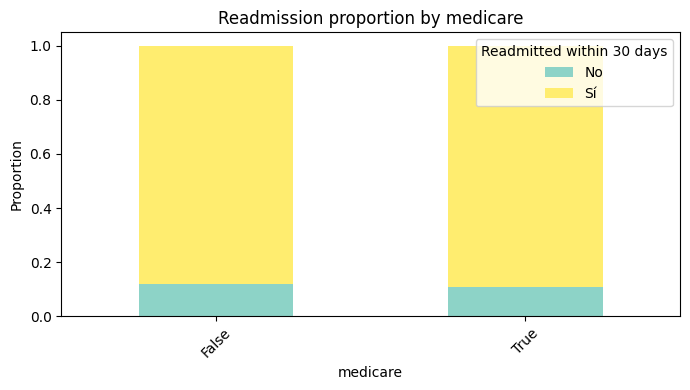

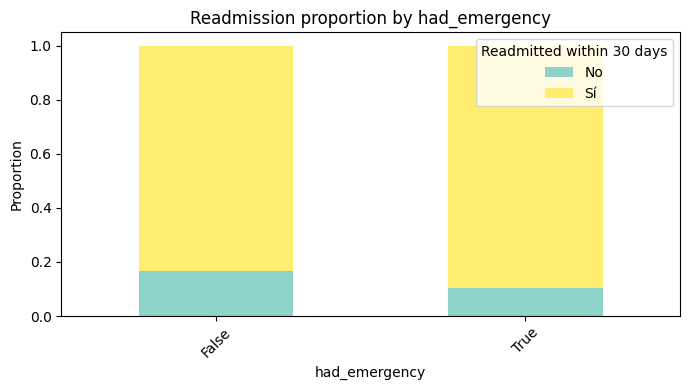

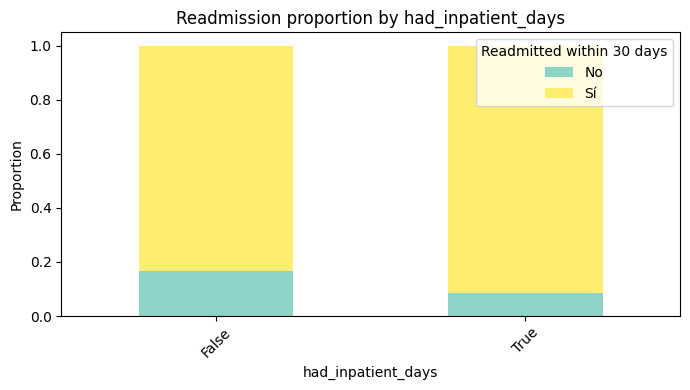

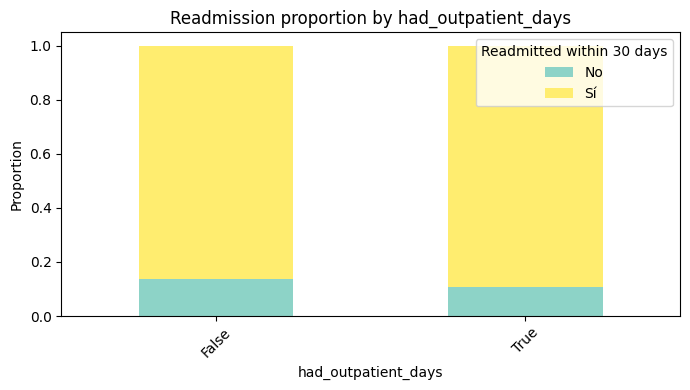

In [192]:
for var in categorical:
    tabla = pd.crosstab(df_grouped[var], df_grouped['readmit_30_days'], normalize='index')
    ax = tabla.plot(kind='bar', stacked=True, figsize=(7, 4), colormap='Set3')
    plt.title(f'Readmission proportion by {var}')
    plt.xlabel(var)
    plt.ylabel('Proportion')
    plt.legend(title='Readmitted within 30 days', labels=['No', 'Sí'])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

##### Chi-Square Test

In [193]:
for var in categorical:
    tabla_contingencia = pd.crosstab(df_grouped[var], df_grouped['readmit_30_days'])
    chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
    print(f"Variable: {var}")
    print(f"Chi-cuadrado: {chi2:.3f}")
    print(f"P-value: {p:.3e}")
    print(f"Degrees of freedom: {dof}")
    print("-" * 30)

Variable: race
Chi-cuadrado: 25.647
P-value: 3.728e-05
Degrees of freedom: 4
------------------------------
Variable: gender
Chi-cuadrado: 0.842
P-value: 3.588e-01
Degrees of freedom: 1
------------------------------
Variable: age
Chi-cuadrado: 45.494
P-value: 1.322e-10
Degrees of freedom: 2
------------------------------
Variable: discharge_disposition_id
Chi-cuadrado: 514.265
P-value: 7.485e-114
Degrees of freedom: 1
------------------------------
Variable: admission_source_id
Chi-cuadrado: 38.781
P-value: 3.791e-09
Degrees of freedom: 2
------------------------------
Variable: medical_specialty
Chi-cuadrado: 74.596
P-value: 1.130e-14
Degrees of freedom: 5
------------------------------
Variable: insulin
Chi-cuadrado: 190.782
P-value: 4.137e-41
Degrees of freedom: 3
------------------------------
Variable: change
Chi-cuadrado: 38.613
P-value: 5.167e-10
Degrees of freedom: 1
------------------------------
Variable: diabetesMed
Chi-cuadrado: 74.656
P-value: 5.602e-18
Degrees of freedom

Finally, according to the p-values obtained from the Chi-Square test, the only variable that could be considered independent from the target variable (with a significance level of 0.05) is gender. Therefore, it could be removed from the model.